<a href="https://colab.research.google.com/github/GoshenEngineer/first-repo/blob/main/Car_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTING THE DEPENDENCIES

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
# importing the performance evaluation metrics
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


Data Collection and Processing

In [2]:
#loading the dataset to the Pandas
df = pd.read_csv(r'C:\Users\Admin\Downloads\Car Prediction Project using Fast Api\cardekho_dataset.csv', index_col = 0)
pd.set_option('display.max_columns', None)
df

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19537,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
19540,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
19541,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
19542,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000


In [3]:
#checking the first ten rows of the dataset
df.head(10)

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
5,Maruti Wagon R,Maruti,Wagon R,8,35000,Individual,Petrol,Manual,18.90,998,67.10,5,350000
6,Hyundai i10,Hyundai,i10,8,40000,Dealer,Petrol,Manual,20.36,1197,78.90,5,315000
7,Maruti Wagon R,Maruti,Wagon R,3,17512,Dealer,Petrol,Manual,20.51,998,67.04,5,410000
8,Hyundai Venue,Hyundai,Venue,2,20000,Individual,Petrol,Automatic,18.15,998,118.35,5,1050000
12,Maruti Swift,Maruti,Swift,4,28321,Dealer,Petrol,Manual,16.60,1197,85.00,5,511000


In [4]:
df2=df.copy()

In [5]:
#printing the last 10 rows of the dataset
df.tail(10)

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
19531,Maruti Swift,Maruti,Swift,3,25000,Individual,Petrol,Automatic,22.00,1197,81.80,5,590000
19533,Honda Amaze,Honda,Amaze,6,28000,Dealer,Diesel,Manual,25.80,1498,98.60,5,525000
19534,Renault KWID,Renault,KWID,2,2700,Dealer,Petrol,Manual,25.17,799,53.30,5,395000
19535,Maruti Ertiga,Maruti,Ertiga,5,56829,Dealer,Diesel,Manual,20.77,1248,88.80,7,895000
19536,Hyundai Grand,Hyundai,Grand,5,9229,Dealer,Petrol,Manual,18.90,1197,82.00,5,545000
19537,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
19540,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
19541,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
19542,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000
19543,Honda City,Honda,City,2,13000,Dealer,Petrol,Automatic,18.00,1497,117.60,5,1200000


In [6]:
# get basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15411 entries, 0 to 19543
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  object 
 1   brand              15411 non-null  object 
 2   model              15411 non-null  object 
 3   vehicle_age        15411 non-null  int64  
 4   km_driven          15411 non-null  int64  
 5   seller_type        15411 non-null  object 
 6   fuel_type          15411 non-null  object 
 7   transmission_type  15411 non-null  object 
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  int64  
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  int64  
 12  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 1.6+ MB


Conclusion from the info: Checking the info of the dataset, the conclusion drawn based on the datatype of each features is that: Most features are object and Integers excluding the mileage and max_power which are in float. The datasets consists of our 13 features in which 6 are categorical(object), 5 are integers(continous) and the remaining features are in float.

In [7]:
df.columns

Index(['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type',
       'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power',
       'seats', 'selling_price'],
      dtype='object')

***Variable Description***


In [8]:
#checking for the numbers of rows and columns in the data Frame#checking for the numbers of rows and columns in the data Frame
df.shape

(15411, 13)

In [9]:
df.isna().sum()

car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [10]:
df.columns

Index(['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type',
       'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power',
       'seats', 'selling_price'],
      dtype='object')

SPECIFIC FEATURES (CATEGORICAL VARIABLE) ANALYSIS

In [11]:
[df[df['brand'].str.startswith('T')]]

[              car_name   brand     model  vehicle_age  km_driven seller_type  \
 21       Toyota Innova  Toyota    Innova            8     110000  Individual   
 35     Toyota Fortuner  Toyota  Fortuner            8     110000  Individual   
 96          Tata Tiago    Tata     Tiago            4      32100  Individual   
 105      Toyota Innova  Toyota    Innova            5     120000  Individual   
 190         Tata Tiago    Tata     Tiago            5       9500  Individual   
 ...                ...     ...       ...          ...        ...         ...   
 19489       Tata Tiago    Tata     Tiago            4      30000  Individual   
 19498      Tata Safari    Tata    Safari           10     120000  Individual   
 19507    Toyota Innova  Toyota    Innova           12      74000      Dealer   
 19516     Toyota Yaris  Toyota     Yaris            3      41000      Dealer   
 19527    Toyota Innova  Toyota    Innova            3      21265  Individual   
 
       fuel_type transmiss

Data Visualization

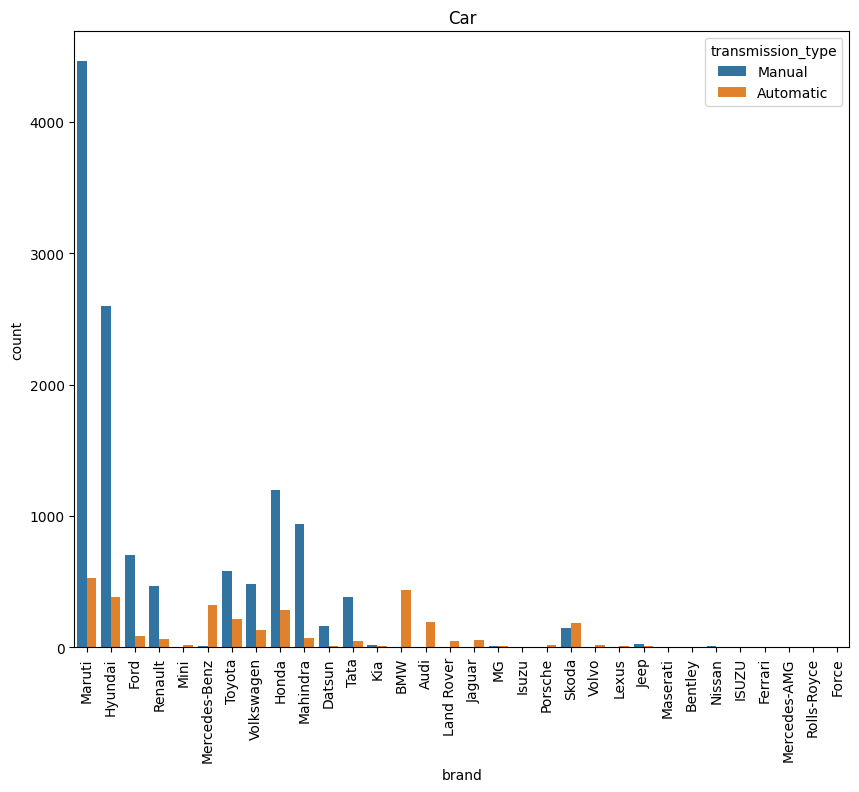

In [12]:
# let's visualize the condition of the house columnn
plt.figure(figsize=(10,8))
sns.countplot(x='brand', data=df, hue = 'transmission_type')
plt.title('Car')
plt.xticks(rotation = 'vertical')
#plt.savefig('Condition of the house')
plt.show()

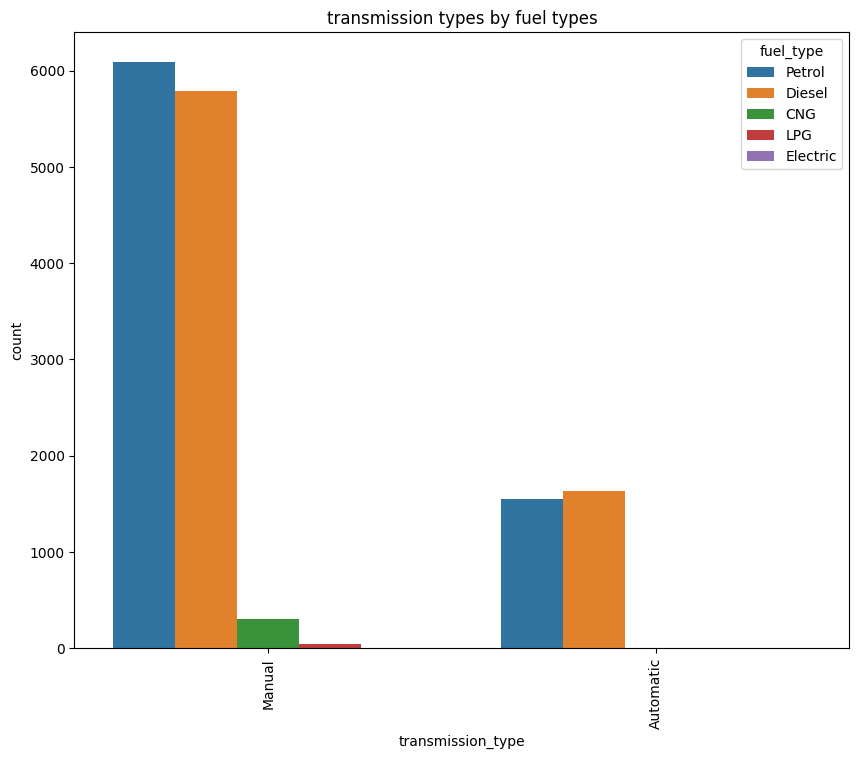

In [13]:
# let's visualize the different fuel types under the transmission types
plt.figure(figsize=(10,8))
sns.countplot(x='transmission_type', data=df, hue = 'fuel_type')
plt.title('transmission types by fuel types')
plt.xticks(rotation = 'vertical')

plt.show()

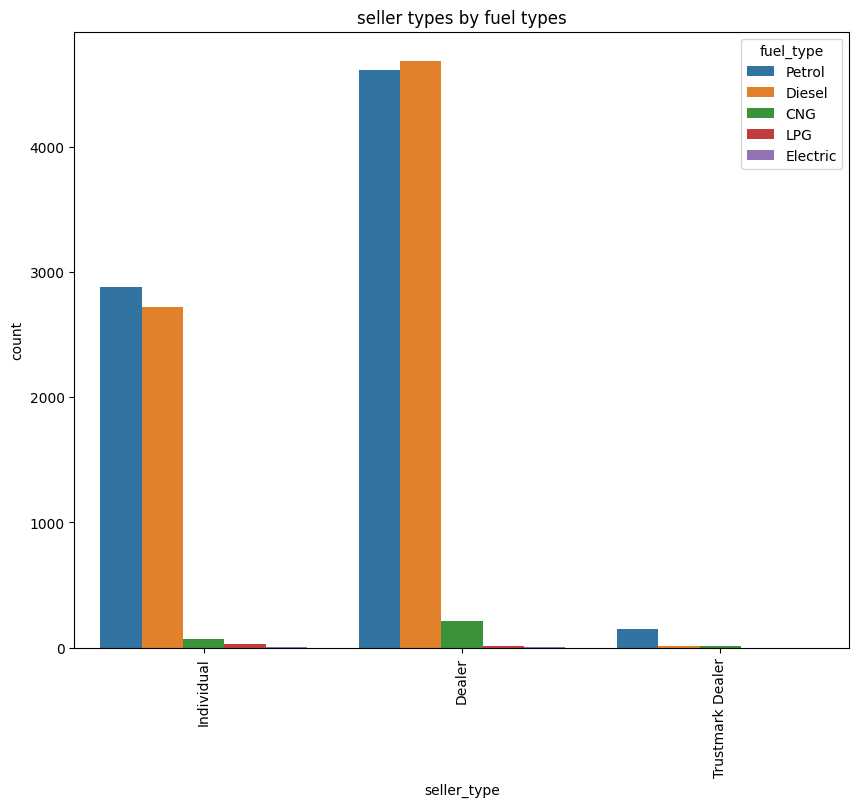

In [14]:
# let's visualize the different fuel types under the transmission types
plt.figure(figsize=(10,8))
sns.countplot(x='seller_type', data = df, hue = 'fuel_type')
plt.title('seller types by fuel types')
plt.xticks(rotation = 'vertical')

plt.show()

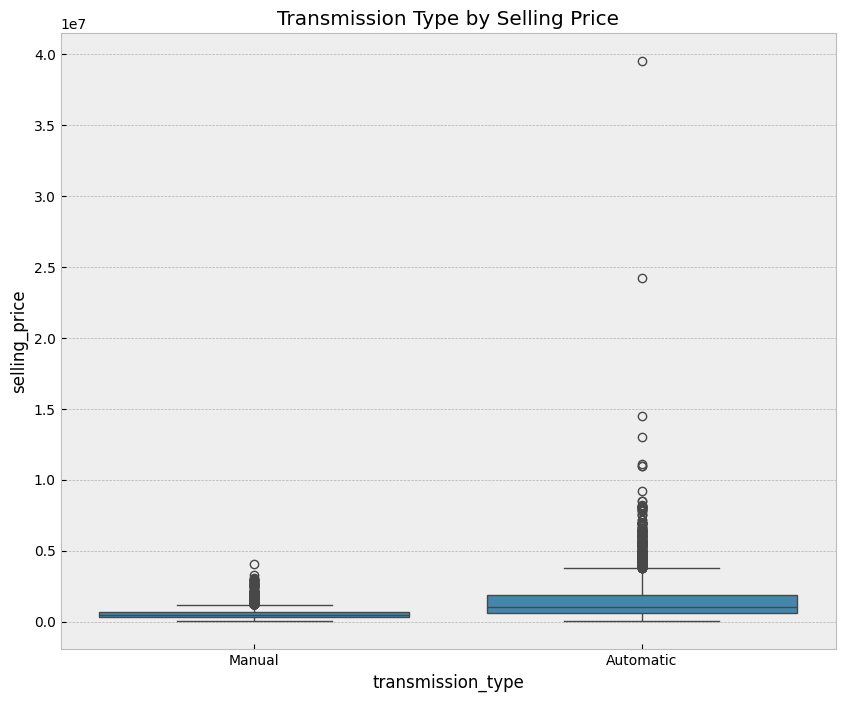

In [15]:
# visuallize the hypertension variable using boxplot
plt.style.use('bmh')
plt.figure(figsize=(10,8))
sns.boxplot(x='transmission_type', y='selling_price',  data=df)
plt.title('Transmission Type by Selling Price')
plt.show()

In [16]:
categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)

In [17]:
categorical_columns

['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

In [18]:
df[['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']]

,car_name,brand,model,seller_type,fuel_type,transmission_type
0,Maruti Alto,Maruti,Alto,Individual,Petrol,Manual
1,Hyundai Grand,Hyundai,Grand,Individual,Petrol,Manual
2,Hyundai i20,Hyundai,i20,Individual,Petrol,Manual
3,Maruti Alto,Maruti,Alto,Individual,Petrol,Manual
4,Ford Ecosport,Ford,Ecosport,Dealer,Diesel,Manual
...,...,...,...,...,...,...
19537,Hyundai i10,Hyundai,i10,Dealer,Petrol,Manual
19540,Maruti Ertiga,Maruti,Ertiga,Dealer,Petrol,Manual
19541,Skoda Rapid,Skoda,Rapid,Dealer,Diesel,Manual
19542,Mahindra XUV500,Mahindra,XUV500,Dealer,Diesel,Manual


In [19]:
df['engine'].unique()

array([ 796, 1197,  998, 1498, 1582, 1461, 1998, 1248, 2143, 2494, 1598,
       1497, 2523, 2982,  999, 1199, 1086, 2179, 1396, 1198, 1590, 1997,
       1493, 1120, 1196, 1186, 1061,  799, 1796, 2993, 1298, 3198, 1995,
       1373, 1591, 1968, 1399, 1047, 1353, 2755, 1395, 2498, 1999, 2953,
       2393, 2967, 2998, 2995, 1956, 1462, 1799, 2499, 1451, 1194, 1798,
       2694, 1496, 1969, 2487, 3604, 1499, 2987, 1599, 2354, 1950, 2148,
       4134, 2400, 1984, 2979, 2609, 2092, 5998, 1330, 2956, 3598, 2362,
        793, 1368, 3597, 1991, 5461, 1343, 2497, 4367, 1797, 3498, 2698,
       1896, 2999, 3855, 4806, 1985, 2771, 2157, 3628, 2198, 2996, 2199,
       4395, 3456, 4663, 2773, 6592, 2495, 1781, 2997, 1597, 2596, 4163])

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15411 entries, 0 to 19543
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  object 
 1   brand              15411 non-null  object 
 2   model              15411 non-null  object 
 3   vehicle_age        15411 non-null  int64  
 4   km_driven          15411 non-null  int64  
 5   seller_type        15411 non-null  object 
 6   fuel_type          15411 non-null  object 
 7   transmission_type  15411 non-null  object 
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  int64  
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  int64  
 12  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 1.6+ MB


In [22]:
numerical_columns = list(df.dtypes[df.dtypes == 'float64'].index) + list(df.dtypes[df.dtypes == 'int64'].index)

In [23]:
numerical_columns

['mileage',
 'max_power',
 'vehicle_age',
 'km_driven',
 'engine',
 'seats',
 'selling_price']

In [24]:
categorical_columns[1:6]

['brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

In [25]:
c = 'brand'

In [26]:
str.upper(c)

'BRAND'

In [27]:
for c in categorical_columns[1:6]:
    print(str.upper(c))
    print(df[c].unique(), df[c].nunique())

BRAND
['Maruti' 'Hyundai' 'Ford' 'Renault' 'Mini' 'Mercedes-Benz' 'Toyota'
 'Volkswagen' 'Honda' 'Mahindra' 'Datsun' 'Tata' 'Kia' 'BMW' 'Audi'
 'Land Rover' 'Jaguar' 'MG' 'Isuzu' 'Porsche' 'Skoda' 'Volvo' 'Lexus'
 'Jeep' 'Maserati' 'Bentley' 'Nissan' 'ISUZU' 'Ferrari' 'Mercedes-AMG'
 'Rolls-Royce' 'Force'] 32
MODEL
['Alto' 'Grand' 'i20' 'Ecosport' 'Wagon R' 'i10' 'Venue' 'Swift' 'Verna'
 'Duster' 'Cooper' 'Ciaz' 'C-Class' 'Innova' 'Baleno' 'Swift Dzire'
 'Vento' 'Creta' 'City' 'Bolero' 'Fortuner' 'KWID' 'Amaze' 'Santro'
 'XUV500' 'KUV100' 'Ignis' 'RediGO' 'Scorpio' 'Marazzo' 'Aspire' 'Figo'
 'Vitara' 'Tiago' 'Polo' 'Seltos' 'Celerio' 'GO' '5' 'CR-V' 'Endeavour'
 'KUV' 'Jazz' '3' 'A4' 'Tigor' 'Ertiga' 'Safari' 'Thar' 'Hexa' 'Rover'
 'Eeco' 'A6' 'E-Class' 'Q7' 'Z4' '6' 'XF' 'X5' 'Hector' 'Civic' 'D-Max'
 'Cayenne' 'X1' 'Rapid' 'Freestyle' 'Superb' 'Nexon' 'XUV300' 'Dzire VXI'
 'S90' 'WR-V' 'XL6' 'Triber' 'ES' 'Wrangler' 'Camry' 'Elantra' 'Yaris'
 'GL-Class' '7' 'S-Presso' 'Dzire LXI' 'Au

In [28]:
df.columns

Index(['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type',
       'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power',
       'seats', 'selling_price'],
      dtype='object')

In [29]:
#Create the features and the Target Varaible
X = df.drop(['car_name','selling_price'], axis = 1)
Y = df['selling_price'] 

In [30]:
len(df['model'].unique())

120

In [31]:
X

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5
1,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5
2,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5
3,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5
4,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5
...,...,...,...,...,...,...,...,...,...,...,...
19537,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5
19540,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7
19541,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5
19542,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7


In [46]:
X.columns

Index(['brand', 'model', 'vehicle_age', 'km_driven', 'seller_type',
       'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power',
       'seats'],
      dtype='object')

In [53]:
X['mileage'].max()

np.float64(33.54)

In [ ]:
df['km_driven'].uniq

In [32]:
type(X.iloc[0,1:])

pandas.core.series.Series

In [33]:
#Split Categorical and Numerical Features
numerical_cols = ['mileage', 'max_power', 'vehicle_age', 'km_driven', 'engine', 'seats']
categorical_cols = [
    'brand', 
    'seller_type', 
    'fuel_type', 
    'transmission_type'
    ]
model_col = ['model'] #high-cardinality

# Numerical pipeline
num_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='mean')),
    ('scale', StandardScaler())
])

# Categorical pipeline (using OrdinalEncoder for embedding layer)
cat_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

model_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Combine into ColumnTransformer
x_preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols),
    ('model', model_pipeline,model_col)
])

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

X_train_poc = x_preprocessor.fit_transform(X_train)

X_test_proc = x_preprocessor.transform(X_test)

In [35]:
import joblib
# Saving it
joblib.dump(x_preprocessor, 'preprocessor.joblib')

['preprocessor.joblib']

In [36]:
from sklearn.preprocessing import StandardScaler
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1, 1))

In [37]:
import joblib
# Saving it
joblib.dump(scaler_y, 'scaler.joblib')

['scaler.joblib']

In [38]:
# Separate last column (model) from the rest
num_cat_train = X_train_poc[:, :-1]
model_train = X_train_poc[:, -1].astype('int32')

num_cat_test = X_test_proc[:, :-1]
model_test = X_test_proc[:, -1].astype('int32')

# get input shapes
print("num_cat_train shape:", num_cat_train.shape)
print("model_train shape:", model_train.shape)

num_cat_train shape: (12328, 10)
model_train shape: (12328,)


In [39]:
model_vocab_size = len(X_train['model'].unique())
embedding_dim = 16  # good starting size
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
#Inputs
num_cat_input = layers.Input(shape=(num_cat_train.shape[1],))
model_input = layers.Input(shape=(1,))
#Embedding for model
embed = layers.Embedding(input_dim=model_vocab_size+1, output_dim=embedding_dim)(model_input)
embed = layers.Flatten()(embed)
#Combine
combined = layers.Concatenate()([num_cat_input, embed])
#Dense layers
x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001))(combined)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(1)(x)  #regression output
#Build + compile
nn_model = models.Model(inputs=[num_cat_input, model_input], outputs=output)
nn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)
#Train
nn_model.fit(
    [num_cat_train, model_train], y_train_scaled,
    validation_data=([num_cat_test, model_test], y_test_scaled),callbacks=[callback],
    epochs=100, batch_size=32
)

Epoch 1/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.7328 - mae: 0.4550 - val_loss: 0.2654 - val_mae: 0.2793
Epoch 2/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3019 - mae: 0.2482 - val_loss: 0.1678 - val_mae: 0.2072
Epoch 3/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2683 - mae: 0.2185 - val_loss: 0.1615 - val_mae: 0.1981
Epoch 4/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2403 - mae: 0.2042 - val_loss: 0.1316 - val_mae: 0.1718
Epoch 5/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2449 - mae: 0.2041 - val_loss: 0.1423 - val_mae: 0.1630
Epoch 6/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2323 - mae: 0.1973 - val_loss: 0.1349 - val_mae: 0.1718
Epoch 7/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2311 - mae: 0.1872 - val_loss: 0.1398 - val_mae: 0.1651
Epoch 8/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2043 - mae: 0.1838 - val_loss: 0.1521 - val_mae: 0.1674
Epoch 9/100
386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

In [40]:
y_pred_scaled = nn_model.predict([num_cat_train, model_train])

386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [41]:
# Convert predictions back to original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled)

In [42]:
y_test[:]

4259      190000
13896     600000
3212      665000
14374    1570000
12058     160000
          ...   
2495      295000
13344     840000
16624     790000
8361      440000
18229     861000
Name: selling_price, Length: 3083, dtype: int64

In [43]:
float(y_pred[0][0])

2169329.5

Save the Model

In [44]:
outfile = "nn_model.keras"

In [45]:
nn_model.save(outfile)

In [ ]:
from tensorflow.keras.models import load_model
loaded_model = load_model("my_model.keras")


In [95]:
import joblib

preprocessor = joblib.load('preprocessor.joblib')


FileNotFoundError: [Errno 2] No such file or directory: 'preprocessor.joblib'